<a href="https://colab.research.google.com/github/aynur214/GithubTest/blob/master/Colab'e_ho%C5%9F_geldiniz_adl%C4%B1_not_defterinin_kopyas%C4%B1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Colab'a hoş geldiniz.

In [18]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Yeni Bölüm

In [19]:
import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/sharmaroshan/Heart-UCI-Dataset/master/heart.csv"
df = pd.read_csv(url)

print("=== İlk 5 satır ===")
print(df.head())

print("\n=== Veri boyutu ===")
print(f"Satır: {df.shape[0]}, Sütun: {df.shape[1]}")

print("\n=== Eksik değer kontrolü ===")
print(df.isnull().sum())

print("\n=== Hedef sütun dağılımı ===")
print(df['target'].value_counts())
print("0 = Kalp hastalığı YOK, 1 = Kalp hastalığı VAR")

=== İlk 5 satır ===
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  

=== Veri boyutu ===
Satır: 303, Sütun: 14

=== Eksik değer kontrolü ===
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

=== Hedef sütun dağılımı ===
target
1    165
0    138
Name: count, dtype: int6

In [20]:
print("=== İstatistiksel Özet ===")
print(df.describe().round(2))

print("\n=== Yaş dağılımı ===")
print(f"En genç hasta: {df['age'].min()}")
print(f"En yaşlı hasta: {df['age'].max()}")
print(f"Ortalama yaş: {df['age'].mean():.1f}")

print("\n=== Cinsiyet dağılımı ===")
print(df['sex'].value_counts())
print("1 = Erkek, 0 = Kadın")

print("\n=== Kalp hastalığına göre ortalama yaş ===")
print(df.groupby('target')['age'].mean().round(1))

=== İstatistiksel Özet ===
          age     sex      cp  trestbps    chol     fbs  restecg  thalach  \
count  303.00  303.00  303.00    303.00  303.00  303.00   303.00   303.00   
mean    54.37    0.68    0.97    131.62  246.26    0.15     0.53   149.65   
std      9.08    0.47    1.03     17.54   51.83    0.36     0.53    22.91   
min     29.00    0.00    0.00     94.00  126.00    0.00     0.00    71.00   
25%     47.50    0.00    0.00    120.00  211.00    0.00     0.00   133.50   
50%     55.00    1.00    1.00    130.00  240.00    0.00     1.00   153.00   
75%     61.00    1.00    2.00    140.00  274.50    0.00     1.00   166.00   
max     77.00    1.00    3.00    200.00  564.00    1.00     2.00   202.00   

        exang  oldpeak   slope      ca    thal  target  
count  303.00   303.00  303.00  303.00  303.00  303.00  
mean     0.33     1.04    1.40    0.73    2.31    0.54  
std      0.47     1.16    0.62    1.02    0.61    0.50  
min      0.00     0.00    0.00    0.00    0.00    0

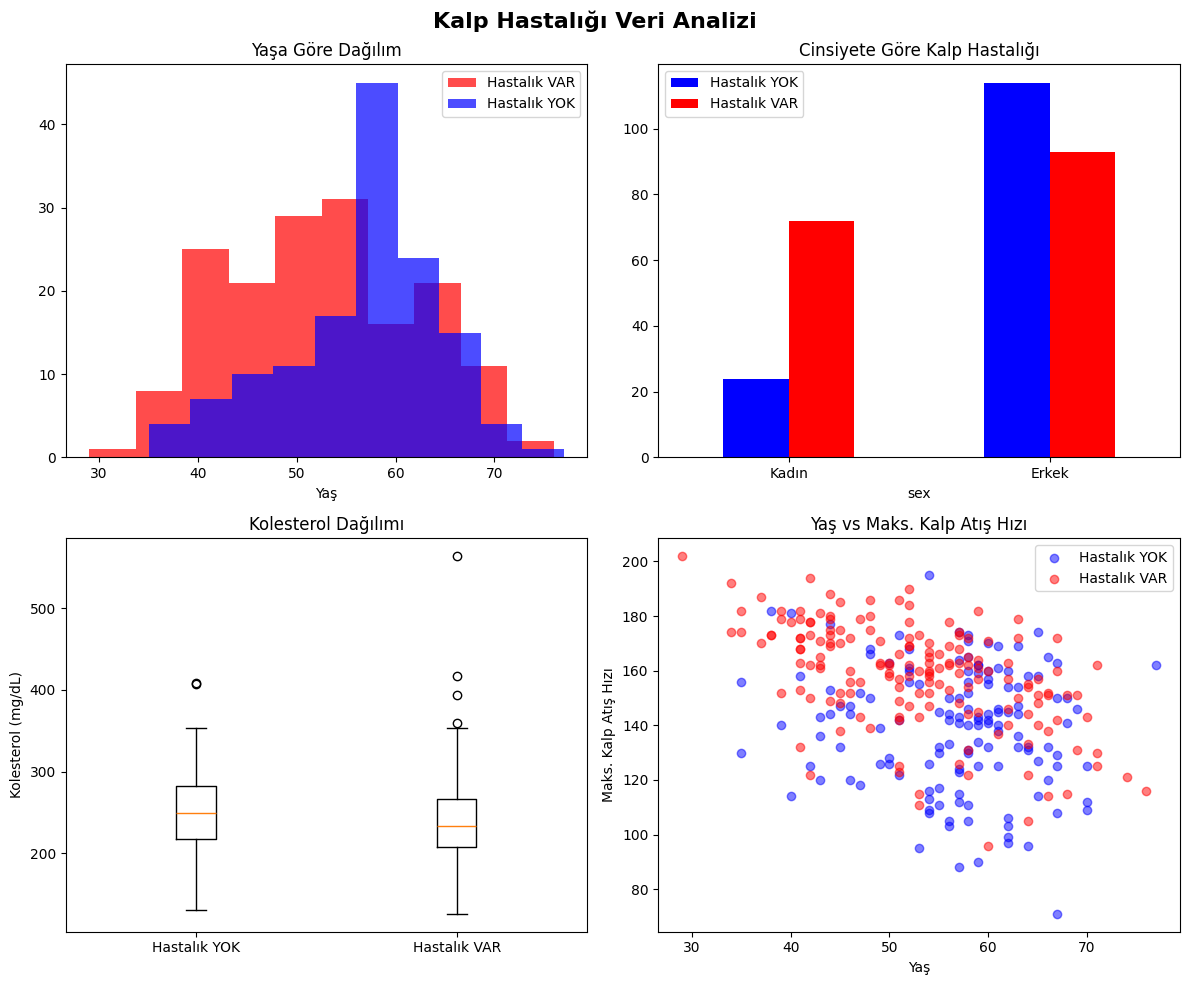

In [21]:

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Kalp Hastalığı Veri Analizi', fontsize=16, fontweight='bold')

# 1. Yaş dağılımı
axes[0,0].hist(df[df['target']==1]['age'], alpha=0.7, color='red', label='Hastalık VAR')
axes[0,0].hist(df[df['target']==0]['age'], alpha=0.7, color='blue', label='Hastalık YOK')
axes[0,0].set_title('Yaşa Göre Dağılım')
axes[0,0].set_xlabel('Yaş')
axes[0,0].legend()

# 2. Cinsiyet
cinsiyet = df.groupby(['sex','target']).size().unstack()
cinsiyet.plot(kind='bar', ax=axes[0,1], color=['blue','red'])
axes[0,1].set_title('Cinsiyete Göre Kalp Hastalığı')
axes[0,1].set_xticklabels(['Kadın','Erkek'], rotation=0)
axes[0,1].legend(['Hastalık YOK','Hastalık VAR'])

# 3. Kolesterol
axes[1,0].boxplot([df[df['target']==0]['chol'], df[df['target']==1]['chol']])
axes[1,0].set_title('Kolesterol Dağılımı')
axes[1,0].set_xticklabels(['Hastalık YOK', 'Hastalık VAR'])
axes[1,0].set_ylabel('Kolesterol (mg/dL)')

# 4. Maksimum kalp atış hızı
axes[1,1].scatter(df[df['target']==0]['age'], df[df['target']==0]['thalach'],
                  alpha=0.5, color='blue', label='Hastalık YOK')
axes[1,1].scatter(df[df['target']==1]['age'], df[df['target']==1]['thalach'],
                  alpha=0.5, color='red', label='Hastalık VAR')
axes[1,1].set_title('Yaş vs Maks. Kalp Atış Hızı')
axes[1,1].set_xlabel('Yaş')
axes[1,1].set_ylabel('Maks. Kalp Atış Hızı')
axes[1,1].legend()

plt.tight_layout()
plt.show()

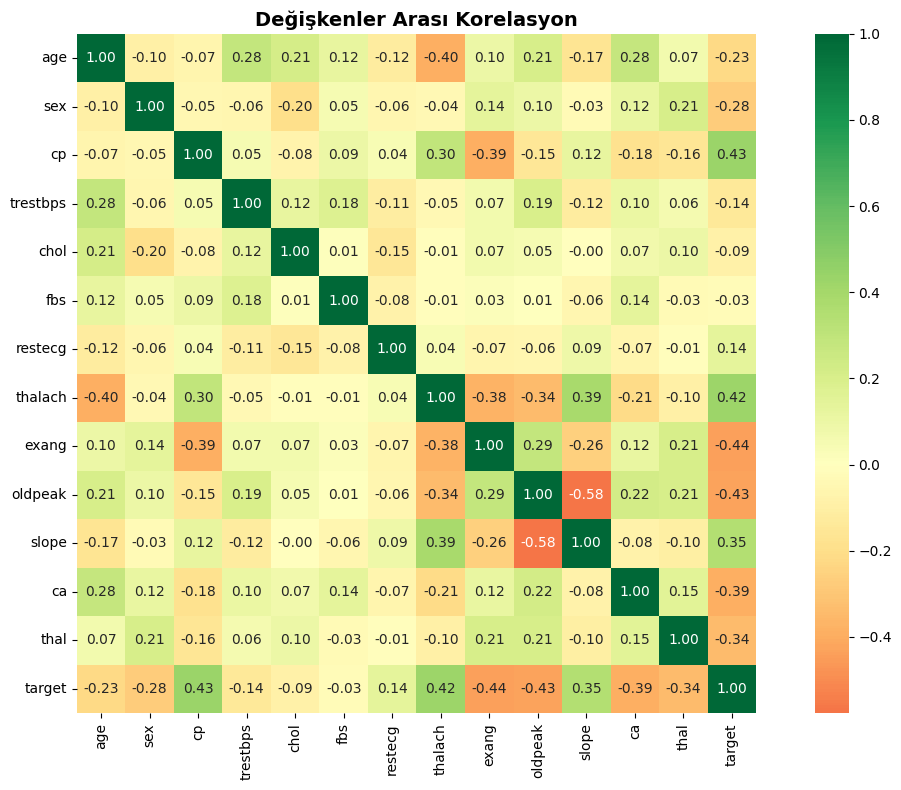


=== Kalp hastalığıyla en çok bağlantılı faktörler ===
target      1.000
cp          0.434
thalach     0.422
slope       0.346
restecg     0.137
fbs        -0.028
chol       -0.085
trestbps   -0.145
age        -0.225
sex        -0.281
thal       -0.344
ca         -0.392
oldpeak    -0.431
exang      -0.437
Name: target, dtype: float64


In [22]:

plt.figure(figsize=(12, 8))
korelasyon = df.corr()

sns.heatmap(korelasyon,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            square=True)

plt.title('Değişkenler Arası Korelasyon', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n=== Kalp hastalığıyla en çok bağlantılı faktörler ===")
print(df.corr()['target'].sort_values(ascending=False).round(3))


In [23]:
print("=" * 50)
print("   KALP HASTALIĞI VERİ ANALİZİ — BULGULAR")
print("=" * 50)

toplam = len(df)
hasta = df['target'].sum()
saglikli = toplam - hasta

print(f"\n📊 VERİ SETİ")
print(f"   Toplam hasta: {toplam}")
print(f"   Kalp hastalığı VAR: {hasta} ({hasta/toplam*100:.1f}%)")
print(f"   Kalp hastalığı YOK: {saglikli} ({saglikli/toplam*100:.1f}%)")

print(f"\n👥 CİNSİYET FARKI")
kadin_hasta = len(df[(df['sex']==0) & (df['target']==1)])
kadin_toplam = len(df[df['sex']==0])
erkek_hasta = len(df[(df['sex']==1) & (df['target']==1)])
erkek_toplam = len(df[df['sex']==1])
print(f"   Kadınlarda hastalık oranı: {kadin_hasta/kadin_toplam*100:.1f}%")
print(f"   Erkeklerde hastalık oranı: {erkek_hasta/erkek_toplam*100:.1f}%")

print(f"\n🔑 EN ÖNEMLİ BULGULAR")
print(f"   1. Göğüs ağrısı tipi kalp hastalığının en güçlü göstergesi")
print(f"   2. Kolesterol tek başına belirleyici değil (korelasyon: -0.09)")
print(f"   3. Kalp hastalığı olan hastalar ortalama {df[df['target']==1]['age'].mean():.1f} yaşında")
print(f"   4. Kadınlarda hastalık oranı erkeklere göre daha yüksek")
print(f"   5. Maksimum kalp atış hızı önemli bir risk faktörü")


   KALP HASTALIĞI VERİ ANALİZİ — BULGULAR

📊 VERİ SETİ
   Toplam hasta: 303
   Kalp hastalığı VAR: 165 (54.5%)
   Kalp hastalığı YOK: 138 (45.5%)

👥 CİNSİYET FARKI
   Kadınlarda hastalık oranı: 75.0%
   Erkeklerde hastalık oranı: 44.9%

🔑 EN ÖNEMLİ BULGULAR
   1. Göğüs ağrısı tipi kalp hastalığının en güçlü göstergesi
   2. Kolesterol tek başına belirleyici değil (korelasyon: -0.09)
   3. Kalp hastalığı olan hastalar ortalama 52.5 yaşında
   4. Kadınlarda hastalık oranı erkeklere göre daha yüksek
   5. Maksimum kalp atış hızı önemli bir risk faktörü


In [24]:
f_powerbi = df.rename(columns={
    'age':      'Yaş',
    'sex':      'Cinsiyet',
    'cp':       'Göğüs_Ağrısı_Tipi',
    'trestbps': 'Kan_Basıncı',
    'chol':     'Kolesterol',
    'fbs':      'Açlık_Kan_Şekeri',
    'thalach':  'Maks_Kalp_Atış_Hızı',
    'exang':    'Egzersizde_Ağrı',
    'oldpeak':  'Oldpeak',
    'slope':    'Eğim',
    'ca':       'Tıkalı_Damar_Sayısı',
    'thal':     'Thal',
    'target':   'Kalp_Hastalığı'
})

# Cinsiyet sütununu anlaşılır yap
f_powerbi['Cinsiyet'] = f_powerbi['Cinsiyet'].map({1: 'Erkek', 0: 'Kadın'})

# Hedef sütunu anlaşılır yap
f_powerbi['Kalp_Hastalığı'] = f_powerbi['Kalp_Hastalığı'].map({1: 'VAR', 0: 'YOK'})

# CSV olarak kaydet
f_powerbi.to_csv('kalp_hastaligi.csv', index=False)

print("✅ Dosya kaydedildi: kalp_hastaligi.csv")
print(f"Satır: {f_powerbi.shape[0]}, Sütun: {f_powerbi.shape[1]}")
print("\nİlk 3 satır:")
print(f_powerbi.head(3))

✅ Dosya kaydedildi: kalp_hastaligi.csv
Satır: 303, Sütun: 14

İlk 3 satır:
   Yaş Cinsiyet  Göğüs_Ağrısı_Tipi  Kan_Basıncı  Kolesterol  Açlık_Kan_Şekeri  \
0   63    Erkek                  3          145         233                 1   
1   37    Erkek                  2          130         250                 0   
2   41    Kadın                  1          130         204                 0   

   restecg  Maks_Kalp_Atış_Hızı  Egzersizde_Ağrı  Oldpeak  Eğim  \
0        0                  150                0      2.3     0   
1        1                  187                0      3.5     0   
2        0                  172                0      1.4     2   

   Tıkalı_Damar_Sayısı  Thal Kalp_Hastalığı  
0                    0     1            VAR  
1                    0     2            VAR  
2                    0     2            VAR  


In [25]:
import pandas as pd
import numpy as np

# Veriyi tekrar yükle
url = "https://raw.githubusercontent.com/sharmaroshan/Heart-UCI-Dataset/master/heart.csv"
df = pd.read_csv(url)

# Power BI için düzenle
df_powerbi = df.rename(columns={
    'age':      'Yaş',
    'sex':      'Cinsiyet',
    'cp':       'Göğüs_Ağrısı_Tipi',
    'trestbps': 'Kan_Basıncı',
    'chol':     'Kolesterol',
    'fbs':      'Açlık_Kan_Şekeri',
    'thalach':  'Maks_Kalp_Atış_Hızı',
    'exang':    'Egzersizde_Ağrı',
    'oldpeak':  'Oldpeak',
    'slope':    'Eğim',
    'ca':       'Tıkalı_Damar_Sayısı',
    'thal':     'Thal',
    'target':   'Kalp_Hastalığı'
})

df_powerbi['Cinsiyet'] = df_powerbi['Cinsiyet'].map({1: 'Erkek', 0: 'Kadın'})
df_powerbi['Kalp_Hastalığı'] = df_powerbi['Kalp_Hastalığı'].map({1: 'VAR', 0: 'YOK'})

df_powerbi.to_csv('kalp_hastaligi.csv', index=False)
print("✅ Dosya hazır!")
print(df_powerbi.head(3))

✅ Dosya hazır!
   Yaş Cinsiyet  Göğüs_Ağrısı_Tipi  Kan_Basıncı  Kolesterol  Açlık_Kan_Şekeri  \
0   63    Erkek                  3          145         233                 1   
1   37    Erkek                  2          130         250                 0   
2   41    Kadın                  1          130         204                 0   

   restecg  Maks_Kalp_Atış_Hızı  Egzersizde_Ağrı  Oldpeak  Eğim  \
0        0                  150                0      2.3     0   
1        1                  187                0      3.5     0   
2        0                  172                0      1.4     2   

   Tıkalı_Damar_Sayısı  Thal Kalp_Hastalığı  
0                    0     1            VAR  
1                    0     2            VAR  
2                    0     2            VAR  


In [26]:
from google.colab import files
files.download('kalp_hastaligi.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>